# DSA 107 — Lab 2: Summarising one variable, then two

**Week 2 · w/c 5 October 2026** · paired with DSA 101 lecture week 2

**Name:** Orhan   **Student ID:** 26022121141

---

### What you will produce

A runnable Colab notebook, pushed to your `dsa107-labs` repository. In it you summarise one categorical variable, count two categorical variables together, turn those counts into rates, summarise one quantitative variable, and draw three labelled figures.

### Before you start

Run the setup cell below. If any import fails, run
`!pip install pandas matplotlib seaborn` in a new cell and try again.

### How to use this notebook

Every code cell has a **Goal** written just above it. Read the goal, then write the code. You do not need to open the handout while you work — everything you have to do is in this notebook.

The **Command reference** below holds the commands you need for this lab, and a few more besides. Read it once now, and come back to it whenever you are stuck.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")
print("pandas", pd.__version__)

pandas 2.2.3


## Command reference

`df` means a whole table (a DataFrame). `s` means a single column (a Series).
Not every command here is needed for this lab — choosing the right one is part of the work.

**Looking at the table**

| Command | What it does |
| --- | --- |
| `pd.read_csv(url)` | reads a CSV file, from a web address or from your computer |
| `df.head(n)` | returns the first `n` rows (5 if you do not say) |
| `df.tail(n)` | returns the last `n` rows |
| `df.shape` | gives (number of rows, number of columns) |
| `len(df)` | gives the number of rows |
| `df.info()` | prints the column names, their types and their non-missing counts |
| `df.describe()` | prints count, mean, std, min, quartiles and max for the numeric columns |

**Missing values, and sorting**

| Command | What it does |
| --- | --- |
| `df.isna().sum()` | gives the number of missing values in each column |
| `s.sort_values()` | sorts from smallest to largest |
| `s.sort_values(ascending=False)` | sorts from largest to smallest |

**One categorical column**

| Command | What it does |
| --- | --- |
| `df["col"]` | picks out one column |
| `s.value_counts()` | counts how many times each value appears |
| `s.value_counts(normalize=True)` | the same, as proportions that add up to 1 |
| `s.sort_index()` | sorts by category name instead of by count |
| `s.nunique()` | counts how many different values there are |

**Two categorical columns together**

| Command | What it does |
| --- | --- |
| `pd.crosstab(a, b)` | counts every combination; `a` runs down the side, `b` across the top |
| `pd.crosstab(a, b, normalize="index")` | divides every cell by its own **row** total |
| `pd.crosstab(a, b, normalize="columns")` | divides every cell by its own **column** total |
| `table.sum(axis="columns")` | adds up each row, giving one total per row |
| `table.sum(axis="index")` | adds up each column, giving one total per column |
| `table.loc[3, 0]` | picks out one cell, by its row label and column label (numbers, no quotes) |

**One quantitative column**

| Command | What it does |
| --- | --- |
| `s.mean()` | the mean: add every value, divide by how many |
| `s.median()` | the median: sort the values and take the middle one |
| `s.std()` | the standard deviation: roughly, the typical distance from the mean |
| `s.min()` / `s.max()` | the smallest / the largest value |
| `round(x, 2)` | rounds one number to 2 decimal places |
| `table.round(3)` | rounds every cell of a table |

**Drawing and labelling**

The `.plot` commands hand you back an *axes* object. Catch it in a variable and you can label it.

| Command | What it does |
| --- | --- |
| `ax = s.plot.bar()` | draws a bar chart, one bar per row, and keeps the axes in `ax` |
| `ax = table.plot.bar()` | draws grouped bars, one group per row |
| `ax = s.plot.hist(bins=20)` | draws a histogram with 20 bins |
| `ax.set_xlabel("...")` | names the horizontal axis |
| `ax.set_ylabel("...")` | names the vertical axis |
| `ax.set_title("...")` | puts a title on the figure |
| `ax.legend(title="...")` | names the legend |
| `plt.show()` | shows the finished figure |

A figure in this course is not finished until it has both axis labels and a title.

## 1. Load the data and look at it

`pd.read_csv` accepts a URL just as happily as a filename.

This is a Titanic passenger list, but **it is not the same file used in the lecture**. Your numbers will not match your lecture notes, and they are not supposed to. The method is what carries over, not the answers.

> **Goal 1a.** Load the CSV into a DataFrame called `titanic`, then show its first five rows.

In [4]:
titanic = pd.read_csv("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv")

# TODO: show the first five rows
titanic.head()
# if we want to show the last fivw rows
# titanic.tail()
# if we want to show specific number simply we write a value inside of the method
# titanic.tail(8)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


> **Goal 1b.** Print the shape of the table, then print the column names, their types and their non-missing counts.

In [5]:
# TODO: print the shape, then call .info()
print(titanic.shape)
titanic.info()
# the .shape method clearly shows the columns and the rows

(891, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB


> **Goal 1c.** Count the missing values in each column, and show the worst column first.

In [8]:
# TODO: count the missing values per column, sorted from most to fewest
titanic.isna().sum().sort_values(ascending=False)
# what if we want to show the missing values sorted from fewest to most
#titanic.isna().sum().sort_values(ascending=True)

,0
deck,688
age,177
embarked,2
embark_town,2
sex,0
pclass,0
survived,0
fare,0
parch,0
sibsp,0


**Q1.** How many rows and how many columns are there, and what does one row represent?
Which column has the most missing values, roughly what fraction of the rows is that, and would you use that column in an analysis?

**A1.** The dataset contains 891 rows and 15 columns. Each individual row represents a single passenger on board the Titanic. The column with the most missing values is deck with 688 missing values. This represents roughly 77% of all rows in the dataset. Since over three quarters of data is missing, meaning any pattern derived directly from it without imputation or a dedicated missingness category would be biased and unreliable.

## 2. One categorical variable

A **categorical** variable puts each row into a group: `sex`, `embarked`, `pclass`.
A **quantitative** variable measures an amount: `age`, `fare`.

Be careful: `pclass` is stored as the numbers 1, 2 and 3, but it is still categorical. The number 2 is a label, not an amount — second class is not "twice" first class. How a variable is *stored* and what kind of variable it *is* are two different questions.

For a categorical variable the summary is a count of every category. That table of counts has a name: the **distribution** of the variable.

> **Goal 2a.** Count how many passengers were in each class. Sort the result by class number, not by count, and store it in a variable called `counts_class` so you can draw it later.

In [11]:
# TODO: counts of each passenger class, in class order, stored as counts_class
counts_class = titanic["pclass"].value_counts().sort_index()
counts_class
# Also if we don't care about the order of the pclass simply we can delete the .sort_index()
# counts_class = titanic["pclass"].value_counts()
# counts_class

,count
pclass,
3,491
1,216
2,184


> **Goal 2b.** Show the same summary as proportions instead of counts, and check that they add up to 1.

In [35]:
# TODO: the same table as proportions, plus a check that they sum to 1
proportions = titanic["pclass"].value_counts(normalize=True).sort_index()
print("Passenger Class Proportions:")
print(proportions)

print("\nSum of proportions:", proportions.sum())
print("Does it sum to 1?", proportions.sum() == 1.0)

Passenger Class Proportions:
pclass
1    0.242424
2    0.206510
3    0.551066
Name: proportion, dtype: float64

Sum of proportions: 1.0
Does it sum to 1? True


> **Goal 2c.** Draw a bar chart of the class counts. Give it an x label, a y label and a title.

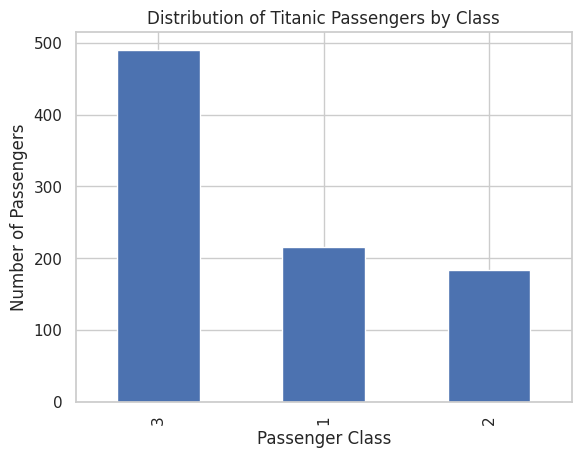

In [15]:
# TODO: labelled bar chart of the class counts
ax = counts_class.plot.bar()
ax.set_xlabel("Passenger Class")
ax.set_ylabel("Number of Passengers")
ax.set_title("Distribution of Titanic Passengers by Class")
plt.show()

**Q2.** What fraction of the passengers travelled in third class?
If you picked one passenger from this dataset at random, what is the probability that they were in first class?
Write one sentence explaining why a proportion and a probability are the same number here.

**A2.** Roughly 55.1% of the passengers travelled in third class. The probability of picking a first-class passenger at random is approximately 0.242. Under the assumption that every passenger in the dataset has an equal chance of being selected, the relative frequency of a category directly defines its theoretical probability.

## 3. Two variables, and the denominator question

One variable on its own cannot answer "did class affect survival". You need the pair.

`pd.crosstab` counts every combination of two variables. The first argument runs down the side of the table, the second runs across the top.

Then comes the hard idea of the week. **The same six numbers become different tables depending on what you divide by, and the denominator is the question you are asking.**

| Table | Divide every cell by | The question it answers |
| --- | --- | --- |
| Joint | the grand total | P(third class **and** died) |
| Marginal | nothing — just add up | P(third class) |
| Conditional | its own row total | P(died **given** third class) |

Only the conditional table compares groups of different sizes fairly, because every row adds up to 1 whatever the size of the group.

> **Goal 3a.** Make a crosstab with `pclass` down the side and `survived` across the top. Store it in a variable called `counts` and print it.

In [16]:
# TODO: build the crosstab and print it
counts = pd.crosstab(titanic["pclass"], titanic["survived"])
counts

survived,0,1
pclass,,
1,80,136
2,97,87
3,372,119


> **Goal 3b.** Add up each row of `counts` to get the number of passengers in each class — the marginal counts. Check that they add up to the number of rows in the dataset.

In [34]:
# TODO: row totals, and a check against len(titanic)
row_totals = counts.sum(axis="columns")
print("Row totals (passengers per class):")
print(row_totals)

print("\nSum of row totals:", row_totals.sum())
print("Total number of rows in titanic:", len(titanic))
print("Do they match?", row_totals.sum() == len(titanic))

Row totals (passengers per class):
pclass
1    216
2    184
3    491
dtype: int64

Sum of row totals: 891
Total number of rows in titanic: 891
Do they match? True


> **Goal 3c.** Build the conditional distribution: every cell divided by its own row total. Store it as `rates`, print it rounded to 3 decimal places, and check that every row adds up to 1.

In [37]:
# TODO: the conditional distribution, rounded to 3 places, plus a row check
rates = pd.crosstab(titanic["pclass"], titanic["survived"], normalize="index")
print("Conditional distribution rates (rounded to 3 decimal places):")
display(rates.round(3))
#display(rates.round(n)) for n decimal places

print("\nCheck: Row sums (should each equal 1.0):")
print(rates.sum(axis="columns"))
#yes they are equal

Conditional distribution rates (rounded to 3 decimal places):


survived,0,1
pclass,,
1,0.370,0.630
2,0.527,0.473
3,0.758,0.242



Check: Row sums (should each equal 1.0):
pclass
1    1.0
2    1.0
3    1.0
dtype: float64


> **Goal 3d.** Draw a bar chart of `rates`, with one group of bars per class. Label both axes, the legend and the title.

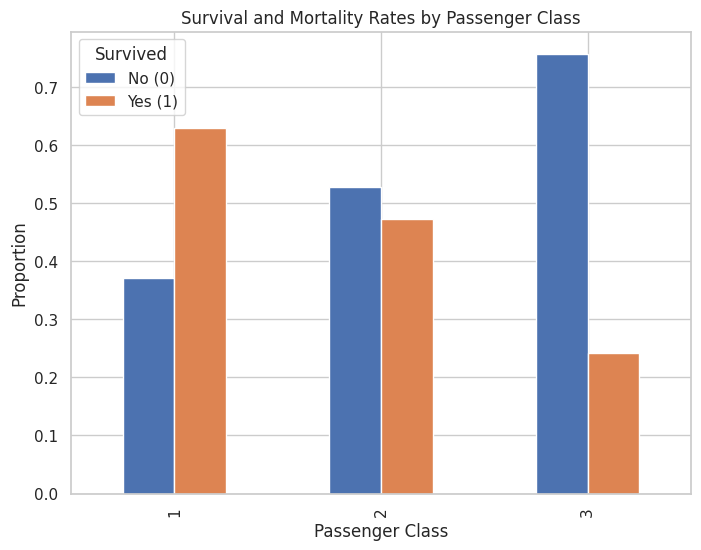

In [38]:
# TODO: labelled bar chart of the conditional rates
ax = rates.plot.bar(figsize=(8, 6))
ax.set_xlabel("Passenger Class")
ax.set_ylabel("Proportion")
ax.set_title("Survival and Mortality Rates by Passenger Class")
ax.legend(title="Survived", labels=["No (0)", "Yes (1)"])
plt.show()

**Q3.** Which single cell of `counts` holds the largest number, and what does that cell mean? Does that number on its own show that this was the most dangerous class to travel in?

Now look at `rates`. Given that a passenger travelled in third class, what fraction survived, and how does that compare with first class?

In one sentence: which of the two tables answers "did class affect survival", and why?

**A3.** The cell with the largest count is third-class deaths with 372 passengers. This raw count alone does not prove third class was the most dangerous, because third class had significantly more passengers overall than any other class. Looking at rates, only about 24.2% of third-class passengers survived, compared to 63.0% in first class. The rates table answers whether class affected survival because normalizing by row totals controls for unequal group sizes and allows a fair comparison of survival probabilities.

## 4. One quantitative variable

`value_counts` is a poor tool for `age`. There are 88 different ages in this dataset, so the table would be 88 rows long, and each row would carry very little information on its own. You cannot see a shape in a table like that.

So instead we cut the range of ages into **bins**, and count how many values fall into each bin. That is a histogram.

The number of bins is a choice you make. Too few bins hide real structure. Too many bins show noise as if it were structure. There is no correct number — only a number you can defend.

> **Goal 4a.** Draw a histogram of `age` with 10 bins. Label both axes and give it a title that says how many bins you used. Then try one other bin count and keep whichever you prefer.

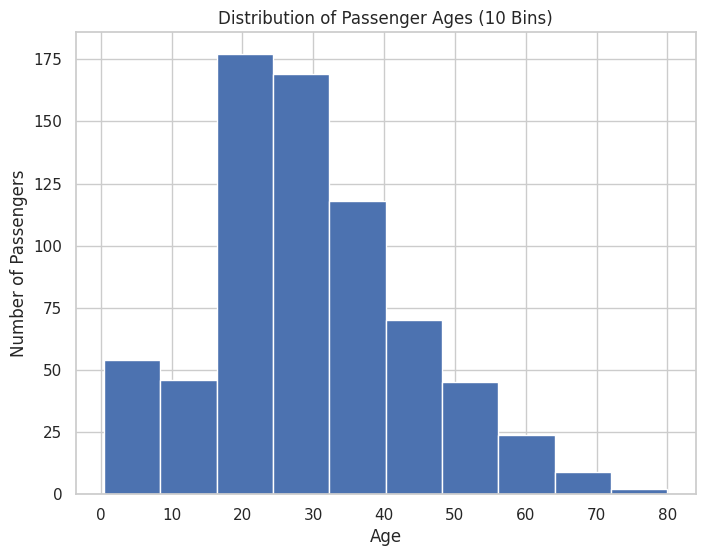

In [42]:
# TODO: labelled histogram of age
ax = titanic["age"].plot.hist(bins=10, figsize=(8, 6))
ax.set_xlabel("Age")
ax.set_ylabel("Number of Passengers")
ax.set_title("Distribution of Passenger Ages (10 Bins)")
plt.show()
# Let's change the bins and see how the plot bar changes
#ax = titanic["age"].plot.hist(bins=20, figsize=(8, 6))
#ax.set_xlabel("Age")
#ax.set_ylabel("Number of Passengers")
#ax.set_title("Distribution of Passenger Ages (20 Bins)")
#plt.show()

> **Goal 4b.** Print the mean, the median and the standard deviation of `age`. Then print the mean, the median and the largest value of `fare`. Round everything to 2 decimal places.

In [45]:
# TODO: centre and spread for age, then centre and largest value for fare
print("Age:")
print("Mean:", round(titanic["age"].mean(), 2))
print("Median:", round(titanic["age"].median(), 2))
print("Standard Deviation:", round(titanic["age"].std(), 2))

print("\nFare:")
print("Mean:", round(titanic["fare"].mean(), 2))
print("Median:", round(titanic["fare"].median(), 2))
print("Largest value:", round(titanic["fare"].max(), 2))

Age:
Mean: 29.7
Median: 28.0
Standard Deviation: 14.53

Fare:
Mean: 32.2
Median: 14.45
Largest value: 512.33


**Q4.** Looking at your age histogram, roughly where is the biggest group of passengers?

**A4.** Looking at the age histogram, the largest group of passengers is concentrated roughly between 20 and 30 years old. For fare, the median (14.45) is the honest summary of a typical fare because it is robust against extreme values, unlike the mean (32.20) which is inflated by very expensive first-class tickets. The large gap between the mean and the median indicates that the fare distribution is heavily right-skewed (positively skewed) with a long upper tail of high outliers.

## 5. Push to GitHub

1. You created a repository named `dsa107-labs` in Lab 1. Use the same one.
2. In Colab: **File → Save a copy in GitHub**, and choose that repository.
3. Paste the resulting link in the line below.

**Repository link:** _______________

---

## Submission checklist

- [ ] Every cell runs top to bottom without error (Runtime → Restart and run all)
- [ ] All three figures have an x label, a y label and a title
- [ ] All four written answers are filled in — a figure with no reading of it scores zero on interpretation
- [ ] Notebook saved as `Lab02_Firstname_Lastname.ipynb`
- [ ] Report exported as `Lab02_Firstname_Lastname.pdf`
- [ ] If you used an AI assistant, the log is attached as described in the course AI policy

Submit both files through MS Teams.